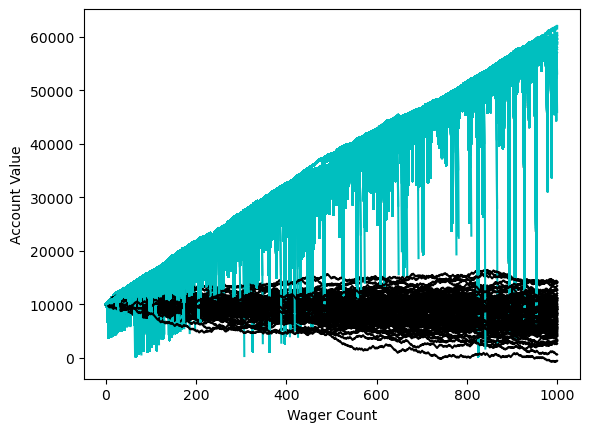

In [4]:
import random
import matplotlib
import matplotlib.pyplot as plt

sampleSize = 100
startingFunds = 10000
wagerSize = 100
wagerCount = 1000

def rollDice(): 
    roll = random.randint(1, 100)

    if roll == 100: 
        #print(roll,'roll was 100, you lose. Play again')
        return False
    elif roll <= 50:
        #print(roll,'roll was 1-50, you lose.')
        return False
    elif 100 > roll > 50: 
        #print(roll,'roll was 51-99, you win!!')
        return True

def double_bettor(funds, initial_wager, wager_count):
    value = funds
    wager = initial_wager
    global broke_count

    wX = []
    vY = []
    
    currentWager = 1
    previousWager = 'win'
    previousWagerAmount = initial_wager

    while currentWager <= wager_count:
        if previousWager == 'win':
            #print('we won')
            if rollDice():
                value += wager
                #print(value)
                wX.append(currentWager)
                vY.append(value)
            else: 
                value -= wager
                previousWager = 'loss'
                #print(value)
                previousWagerAmount = wager
                wX.append(currentWager)
                vY.append(value)
                if value < 0:
                    #print('we went broke after',currentWager,'bets')
                    broke_count += 1
                    break

        elif previousWager == 'loss':
            #print('we lost so we double based on martingale strategy')
            if rollDice():
                wager = previousWagerAmount * 2
                #print('we won',wager)
                value += wager
                #print(value)
                wager = initial_wager
                previousWager = 'win'
                wX.append(currentWager)
                vY.append(value)
            else: 
                wager = previousWagerAmount * 2
                #print('we lost',wager)
                value -= wager
                if value < 0: 
                    #print('we went broke after',currentWager,'bets')
                    broke_count += 1
                    break

                #print(value)
                previousWager = 'loss'

                previousWagerAmount = wager
                wX.append(currentWager)
                vY.append(value)

        currentWager += 1

        #print(value)
        plt.plot(wX, vY, 'c')

'''xx = 0
broke_count = 0

while xx < 100:
    double_bettor(10000, 100, 100)
    xx += 1

print('death rate double', (broke_count/float(xx)) * 100)
print('survival rate double', 100 - ((broke_count/float(xx)) * 100))

plt.axhline(0, color =  'r')

plt.show()'''

def simple_bettor(funds, initial_wager, wager_count):
    global broke_count_simple
    value = funds
    wager = initial_wager

    wX = []
    vY = []
    
    currentWager = 1

    while currentWager <= wager_count: #if returns True (win)
        if rollDice():
            value += wager
            wX.append(currentWager)
            vY.append(value)
        else:
            value -= wager
            wX.append(currentWager)
            vY.append(value)

        currentWager += 1

    if value < 0:
        value = 'broke'
        broke_count_simple += 1
        
    #print('Funds', value)

    plt.plot(wX, vY, 'k')

x = 0 
broke_count_simple = 0
while x < sampleSize: 
    simple_bettor(startingFunds, wagerSize, wagerCount)
    double_bettor(startingFunds, wagerSize, wagerCount)
    x += 1

#print('death rate simple', (broke_count_simple/float(x)) * 100)
#print('survival rate simple', 100 - ((broke_count_simple/float(x)) * 100))

plt.ylabel('Account Value')
plt.xlabel('Wager Count')
plt.show()